## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001625F6492D0> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
years = range(2024, 2025)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled_mean_rain_shp.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2024 | (495414, 44)


In [6]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [7]:
del df
del timelines

gc.collect()

270

In [8]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.155490,39.679430,0,2024-01-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.000000,13651.000000,1.164514,1,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.600000,13889.960000,1.164514,1.164514,1.164514,1.164514,2.000000,3,3
1,21.155490,39.679430,0,2024-01-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.000000,13651.000000,11.846938,2,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.600000,13889.960000,13.011452,13.011452,13.011452,13.011452,2.000000,3,3
2,21.155490,39.679430,0,2024-01-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.000000,13651.000000,0.714449,3,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.600000,13889.960000,13.725901,13.725901,13.725901,13.725901,2.000000,3,3
3,21.155490,39.679430,0,2024-01-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13844.000000,13724.000000,0.000000,4,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.600000,13889.960000,13.725901,13.725901,13.725901,13.725901,2.000000,3,3
4,21.155490,39.679430,0,2024-01-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,13863.000000,13643.000000,0.250432,5,13607.903226,13633.967742,13652.862069,13682.965517,13892.000000,13649.096774,14751.600000,13889.960000,13.976333,13.976333,13.976333,13.976333,2.000000,3,3


In [9]:
timeline_file.shape

(495414, 44)

In [10]:
# wnv_file.head()

In [11]:
# wnv_file.shape

In [12]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [13]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [14]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.155490,39.679430,0,2024-01-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,3.730000,-0.130000,1.164514,1,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,1.164514,1.164514,1.164514,1.164514,2.000000,3,3
1,21.155490,39.679430,0,2024-01-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,3.730000,-0.130000,11.846938,2,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,13.011452,13.011452,13.011452,13.011452,2.000000,3,3
2,21.155490,39.679430,0,2024-01-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,3.730000,-0.130000,0.714449,3,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,13.725901,13.725901,13.725901,13.725901,2.000000,3,3
3,21.155490,39.679430,0,2024-01-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,3.730000,1.330000,0.000000,4,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,13.725901,13.725901,13.725901,13.725901,2.000000,3,3
4,21.155490,39.679430,0,2024-01-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,4.110000,-0.290000,0.250432,5,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,13.976333,13.976333,13.976333,13.976333,2.000000,3,3


In [15]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [16]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [17]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [18]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,21.155490,39.679430,0,2024-01-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,3.730000,-0.130000,1.164514,1,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,1.164514,1.164514,1.164514,1.164514,2.000000,3,3,1.800000,-0.731290,0.208276,2.260968,13.265600,0.500000,0.866025
1,21.155490,39.679430,0,2024-01-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,3.730000,-0.130000,11.846938,2,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,13.011452,13.011452,13.011452,13.011452,2.000000,3,3,1.800000,-0.731290,0.208276,2.260968,13.265600,0.500000,0.866025
2,21.155490,39.679430,0,2024-01-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,3.730000,-0.130000,0.714449,3,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,13.725901,13.725901,13.725901,13.725901,2.000000,3,3,1.800000,-0.731290,0.208276,2.260968,13.265600,0.500000,0.866025
3,21.155490,39.679430,0,2024-01-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,3.730000,1.330000,0.000000,4,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,13.725901,13.725901,13.725901,13.725901,2.000000,3,3,2.530000,-0.731290,0.208276,2.260968,13.265600,0.500000,0.866025
4,21.155490,39.679430,0,2024-01-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2024,1,0.511748,0.258288,-0.470457,-0.258288,0.428874,0.342719,-0.366368,-0.342719,0.146795,0.096576,0.108932,0.096576,4.110000,-0.290000,0.250432,5,-0.991935,-0.470645,-0.092759,0.509310,4.690000,-0.168065,21.882000,4.649200,13.976333,13.976333,13.976333,13.976333,2.000000,3,3,1.910000,-0.731290,0.208276,2.260968,13.265600,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495409,24.067210,39.338070,3237,2024-05-28,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2024,5,0.436893,0.030013,-0.412045,-0.030013,0.363871,0.042370,-0.291696,-0.042370,0.148894,0.086673,0.207093,0.086673,27.830000,18.410000,0.000000,28,13.820323,8.723548,14.452759,11.056897,15.613226,10.404839,20.425200,13.986800,0.471549,27.405561,90.684940,746.164222,2.000000,2,1,23.120000,11.271935,12.754828,13.009032,17.206000,0.500000,-0.866025
495410,24.067210,39.338070,3237,2024-05-29,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2024,5,0.286225,0.060863,-0.228535,-0.060863,0.226291,0.081376,-0.121595,-0.081376,0.105870,0.065469,0.154644,0.065469,27.830000,18.410000,0.000000,29,13.820323,8.723548,14.452759,11.056897,15.613226,10.404839,20.425200,13.986800,0.362378,27.405561,90.684940,746.164222,2.000000,2,1,23.120000,11.271935,12.754828,13.009032,17.206000,0.500000,-0.866025
495411,24.067210,39.338070,3237,2024-05-30,EL6,κεν

In [19]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [20]:
gc.collect()

0

In [21]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [22]:
del timeline_file
gc.collect()

0

In [23]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [24]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [25]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2024-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,1.000000,0.371725,0.442767,-0.361823,-0.442767,0.257971,0.519864,-0.230535,-0.519864,0.137063,0.097580,0.100163,0.097580,-0.991935,-0.470645,-0.731290,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,5.160428,0.877919,33.839919,158.808756,159.973270,-6.510000,-1.830000,4.110000,1.330000,159.973270
1,0,2024-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,2.000000,0.382497,0.308098,-0.371832,-0.308098,0.316973,0.414177,-0.290961,-0.414177,0.144727,0.110431,0.107920,0.110431,-0.092759,0.509310,0.208276,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,2.444708,45.889599,45.918399,70.896519,230.869789,-6.510000,-1.830000,3.470000,3.130000,70.896519
2,0,2024-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,3.000000,0.396450,0.328166,-0.388651,-0.328166,0.360011,0.320641,-0.337045,-0.320641,0.112808,0.113910,0.076133,0.113910,4.690000,-0.168065,2.260968,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,4.030689,10.146586,21.433531,112.105071,351.790460,-2.730000,-5.150000,20.790000,5.610000,120.920671
3,0,2024-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,4.000000,0.494387,0.275380,-0.457889,-0.275380,0.469462,0.259850,-0.428911,-0.259850,0.084973,0.113481,0.051440,0.113481,21.882000,4.649200,13.265600,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,3.242630,9.256397,85.725295,94.036259,445.826719,13.050000,0.390000,26.570000,9.930000,94.036259
4,0,2024-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,5.000000,0.598017,0.280979,-0.513968,-0.280979,0.563763,0.257220,-0.481059,-0.257220,0.041074,0.067323,0.026296,0.067323,18.147857,5.540000,11.843929,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,1.602663,10.844357,18.462488,48.079895,493.906614,11.450000,0.350000,24.390000,11.970000,48.079895


In [26]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2024-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,1.000000,0.371725,0.442767,-0.361823,-0.442767,0.257971,0.519864,-0.230535,-0.519864,0.137063,0.097580,0.100163,0.097580,-0.991935,-0.470645,-0.731290,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,5.160428,0.877919,33.839919,158.808756,159.973270,-6.510000,-1.830000,4.110000,1.330000,159.973270
1,0,2024-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,2.000000,0.382497,0.308098,-0.371832,-0.308098,0.316973,0.414177,-0.290961,-0.414177,0.144727,0.110431,0.107920,0.110431,-0.092759,0.509310,0.208276,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,2.444708,45.889599,45.918399,70.896519,230.869789,-6.510000,-1.830000,3.470000,3.130000,70.896519
2,0,2024-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,3.000000,0.396450,0.328166,-0.388651,-0.328166,0.360011,0.320641,-0.337045,-0.320641,0.112808,0.113910,0.076133,0.113910,4.690000,-0.168065,2.260968,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,4.030689,10.146586,21.433531,112.105071,351.790460,-2.730000,-5.150000,20.790000,5.610000,120.920671
3,0,2024-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,4.000000,0.494387,0.275380,-0.457889,-0.275380,0.469462,0.259850,-0.428911,-0.259850,0.084973,0.113481,0.051440,0.113481,21.882000,4.649200,13.265600,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,3.242630,9.256397,85.725295,94.036259,445.826719,13.050000,0.390000,26.570000,9.930000,94.036259
4,0,2024-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2024.000000,5.000000,0.598017,0.280979,-0.513968,-0.280979,0.563763,0.257220,-0.481059,-0.257220,0.041074,0.067323,0.026296,0.067323,18.147857,5.540000,11.843929,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,1.602663,10.844357,18.462488,48.079895,493.906614,11.450000,0.350000,24.390000,11.970000,48.079895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19423,3237,2024-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2.000000,2.000000,1.000000,2024.000000,2.000000,0.451555,0.105582,-0.372067,-0.105582,0.393618,0.184739,-0.250613,-0.184739,0.180290,0.079482,0.242778,0.079482,14.452759,11.056897,12.754828,13.820323,14.452759,15.613226,20.425200,8.723548,11.056897,10.404839,13.986800,11.271935,12.754828,13.009032,17.206000,2.981467,21.946796,46.821482,88.943384,381.528555,7.290000,4.630000,18.010000,13.710000,86.462555
19424,3237,2024-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2.00

In [27]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [28]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [29]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [30]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2024-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,1,0.371725,0.442767,-0.361823,-0.442767,0.257971,0.519864,-0.230535,-0.519864,0.137063,0.097580,0.100163,0.097580,-0.991935,-0.470645,-0.731290,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,5.160428,0.877919,33.839919,158.808756,159.973270,159.973270,-6.510000,4.110000
1,0,2024-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,2,0.382497,0.308098,-0.371832,-0.308098,0.316973,0.414177,-0.290961,-0.414177,0.144727,0.110431,0.107920,0.110431,-0.092759,0.509310,0.208276,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,2.444708,45.889599,45.918399,70.896519,230.869789,70.896519,-6.510000,3.470000
2,0,2024-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,3,0.396450,0.328166,-0.388651,-0.328166,0.360011,0.320641,-0.337045,-0.320641,0.112808,0.113910,0.076133,0.113910,4.690000,-0.168065,2.260968,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,4.030689,10.146586,21.433531,112.105071,351.790460,120.920671,-5.150000,20.790000
3,0,2024-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,4,0.494387,0.275380,-0.457889,-0.275380,0.469462,0.259850,-0.428911,-0.259850,0.084973,0.113481,0.051440,0.113481,21.882000,4.649200,13.265600,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,3.242630,9.256397,85.725295,94.036259,445.826719,94.036259,0.390000,26.570000
4,0,2024-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,5,0.598017,0.280979,-0.513968,-0.280979,0.563763,0.257220,-0.481059,-0.257220,0.041074,0.067323,0.026296,0.067323,18.147857,5.540000,11.843929,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,1.602663,10.844357,18.462488,48.079895,493.906614,48.079895,0.350000,24.390000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19423,3237,2024-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2,2,1,2024,2,0.451555,0.105582,-0.372067,-0.105582,0.393618,0.184739,-0.250613,-0.184739,0.180290,0.079482,0.242778,0.079482,14.452759,11.056897,12.754828,13.820323,14.452759,15.613226,20.425200,8.723548,11.056897,10.404839,13.986800,11.271935,12.754828,13.009032,17.206000,2.981467,21.946796,46.821482,88.943384,381.528555,86.462555,4.630000,18.010000
19424,3237,2024-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2,2,1,2024,3,0.399425,0.101948,-0.333944,-0.101948,0.346013,0.131459,-0.254782,-0.131459,0.127266,0.060642,0.152616,0.060642,15.613226,10.404839,13.009032,13.820323,14.452759,15.613226,20.425200,8.723548,11.056897,10.404839,13.986800,11.271935,12.754828,13.009032,17.206000,5.214169,22.647027,43.796550,92.848082,537.953624,156.425069,4.850000,21.910000
19425,3237,2024-04,

### Add Geomorphological and Land Cover/Use

In [31]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [32]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [33]:
dataset_locations

,x,y
0,21.155490,39.679430
1,21.178600,39.625530
2,21.178600,39.643500
3,21.178600,39.661470
4,21.178600,39.679430
...,...,...
4129,23.905450,39.194330
4130,23.905450,39.194330
4131,23.905450,39.212300
4132,23.928560,39.230270


In [34]:
dataset_locations_per_year

,x,y,year
0,21.155490,39.679430,2024
1,21.178600,39.625530,2024
2,21.178600,39.643500,2024
3,21.178600,39.661470,2024
4,21.178600,39.679430,2024
...,...,...,...
4129,23.905450,39.194330,2024
4130,23.905450,39.194330,2024
4131,23.905450,39.212300,2024
4132,23.928560,39.230270,2024


In [35]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [36]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 5.484765420413403e-06
Max distance: 0.00044491104150597155


In [37]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_24676\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [38]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
1,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
2,21.178600,39.643500,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.000000,6.601146
3,21.178600,39.661470,21965.416299,1733.325556,34,191.955968,1620.724029,160.444289,0.000000,1.083714
4,21.178600,39.679430,22033.224264,260.405756,30,153.670171,1315.825652,176.453106,0.000000,45.035704
...,...,...,...,...,...,...,...,...,...,...
4129,23.905450,39.194330,1605.267341,48889.605025,12,212.128782,260.256967,168.750910,0.000000,3.803597
4130,23.905450,39.194330,1605.267341,48889.605025,12,212.128782,260.256967,168.750910,0.000000,3.803597
4131,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
4132,23.928560,39.230270,1155.267987,50961.680408,14,180.778128,269.381324,170.808592,0.000000,1.553148


In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [41]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [42]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
1,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
2,21.178600,39.643500,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.000000,6.601146
3,21.178600,39.661470,21965.416299,1733.325556,34,191.955968,1620.724029,160.444289,0.000000,1.083714
4,21.178600,39.679430,22033.224264,260.405756,30,153.670171,1315.825652,176.453106,0.000000,45.035704
...,...,...,...,...,...,...,...,...,...,...
4129,23.905450,39.194330,1605.267341,48889.605025,12,212.128782,260.256967,168.750910,0.000000,3.803597
4130,23.905450,39.194330,1605.267341,48889.605025,12,212.128782,260.256967,168.750910,0.000000,3.803597
4131,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
4132,23.928560,39.230270,1155.267987,50961.680408,14,180.778128,269.381324,170.808592,0.000000,1.553148


In [43]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [44]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [45]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [46]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [47]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [48]:
landcover_2024= landcover_2023 = landcover_2022

In [49]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2024
Min distance: 5.484765420413403e-06
Max distance: 0.00044491104150597155


In [50]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [51]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.155490,39.679430,2024,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
1,21.178600,39.625530,2024,31,98,36,98.000000,30,98,12,12,1,6,7,2,0
2,21.178600,39.643500,2024,21,81,20,81.000000,20,81,8,8,4,1,1,2,0
3,21.178600,39.661470,2024,31,97,36,95.000000,30,97,12,12,1,6,7,2,0
4,21.178600,39.679430,2024,22,80,25,75.000000,20,80,14,9,4,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4129,23.905450,39.194330,2024,21,82,20,82.000000,20,82,8,8,4,2,2,2,0
4130,23.905450,39.194330,2024,21,82,20,82.000000,20,82,8,8,4,2,2,2,0
4131,23.905450,39.212300,2024,21,92,20,92.000000,20,92,8,8,4,1,1,2,0
4132,23.928560,39.230270,2024,21,78,20,78.000000,20,78,8,8,4,1,1,2,0


In [52]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [53]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [54]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [55]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [56]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2024,1,159.973270,-6.510000,4.110000
1,0,2024,2,70.896519,-6.510000,3.470000
2,0,2024,3,120.920671,-5.150000,20.790000
3,0,2024,4,94.036259,0.390000,26.570000
4,0,2024,5,48.079895,0.350000,24.390000
5,0,2024,6,0.000000,NaN,NaN
6,1,2024,1,159.973270,-6.750000,7.270000
7,1,2024,2,70.896519,-4.230000,5.330000
8,1,2024,3,120.920671,-3.170000,21.170000
9,1,2024,4,94.036259,1.370000,26.350000


In [57]:
# wnv_file.head(5)

In [58]:
# wnv_file

In [59]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19428 entries, 0 to 19427
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype    
---  ------               --------------  -----    
 0   cell_number          19428 non-null  int64    
 1   dt_placement         19428 non-null  period[M]
 2   NUTS1_ID             19428 non-null  object   
 3   NUTS1_NAME           19428 non-null  object   
 4   NUTS2_ID             19428 non-null  object   
 5   NUTS2_NAME           19428 non-null  object   
 6   NUTS3_ID             19428 non-null  object   
 7   NUTS3_NAME           19428 non-null  object   
 8   LAU1_NAME            19428 non-null  object   
 9   x                    19428 non-null  float64  
 10  y                    19428 non-null  float64  
 11  MOUNT_TYPE           19428 non-null  int32    
 12  URBN_TYPE            19428 non-null  int32    
 13  COAST_TYPE           19428 non-null  int32    
 14  year                 19428 non-null  int32    
 15  mo

In [60]:
# wnv_file.info()

In [61]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [62]:
# wnv_file.info()

In [63]:
# wnv_file

In [64]:
# wnv_file['cases'].value_counts()

In [65]:
# wnv_file.cases.sum()

In [66]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [67]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2024-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,1,0.371725,0.442767,-0.361823,-0.442767,0.257971,0.519864,-0.230535,-0.519864,0.137063,0.097580,0.100163,0.097580,-0.991935,-0.470645,-0.731290,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,5.160428,0.877919,33.839919,158.808756,159.973270,159.973270,-6.510000,4.110000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
1,0,2024-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,2,0.382497,0.308098,-0.371832,-0.308098,0.316973,0.414177,-0.290961,-0.414177,0.144727,0.110431,0.107920,0.110431,-0.092759,0.509310,0.208276,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,2.444708,45.889599,45.918399,70.896519,230.869789,70.896519,-6.510000,3.470000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
2,0,2024-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,3,0.396450,0.328166,-0.388651,-0.328166,0.360011,0.320641,-0.337045,-0.320641,0.112808,0.113910,0.076133,0.113910,4.690000,-0.168065,2.260968,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,4.030689,10.146586,21.433531,112.105071,351.790460,120.920671,-5.150000,20.790000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
3,0,2024-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,4,0.494387,0.275380,-0.457889,-0.275380,0.469462,0.259850,-0.428911,-0.259850,0.084973,0.113481,0.051440,0.113481,21.882000,4.649200,13.265600,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,3.242630,9.256397,85.725295,94.036259,445.826719,94.036259,0.390000,26.570000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
4,0,2024-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,5,0.598017,0.280979,-0.513968,-0.280979,0.563763,0.257220,-0.481059,-0.257220,0.041074,0.067323,0.026296,0.067323,18.147857,5.540000,11.843929,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,1.602663,10.844357,18.462488,48.079895,493.906614,48.079895,0.350000,24.390000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [68]:
# merged = fillna(merged,{'cases': 0})

In [69]:
# merged['cases'].value_counts()

In [70]:
# merged.cases.sum()

In [71]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

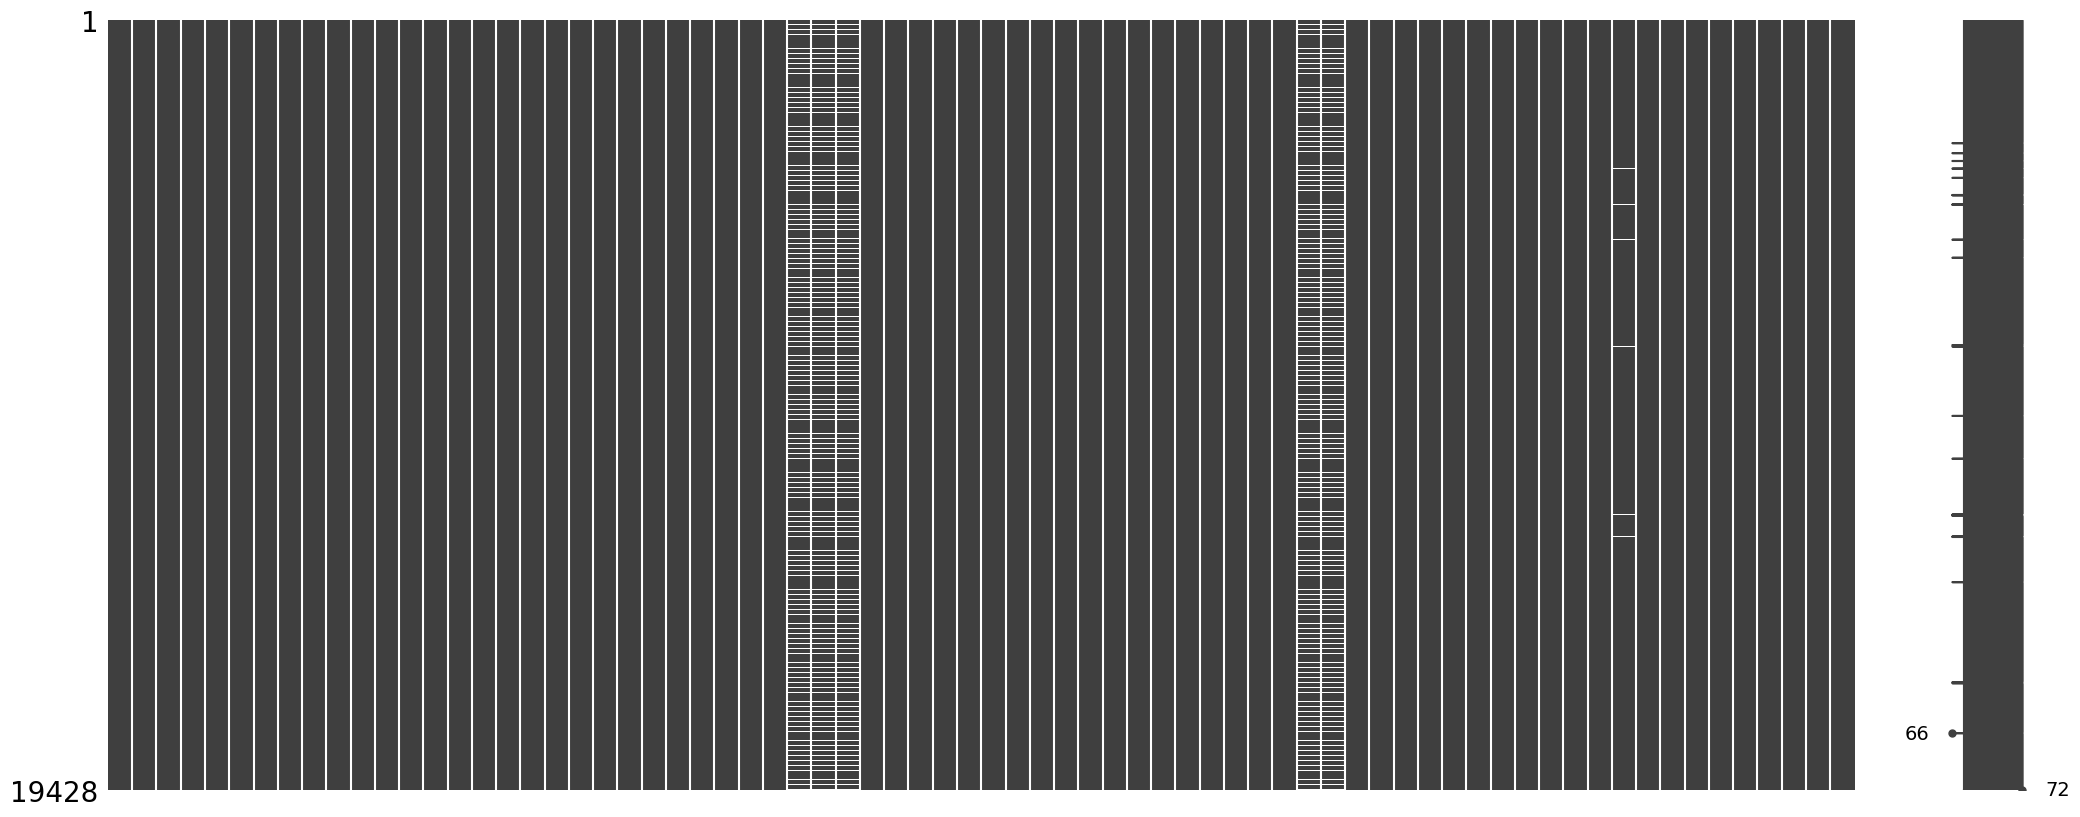

In [72]:
missingno.matrix(merged)

In [73]:
gc.collect()

0

In [74]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

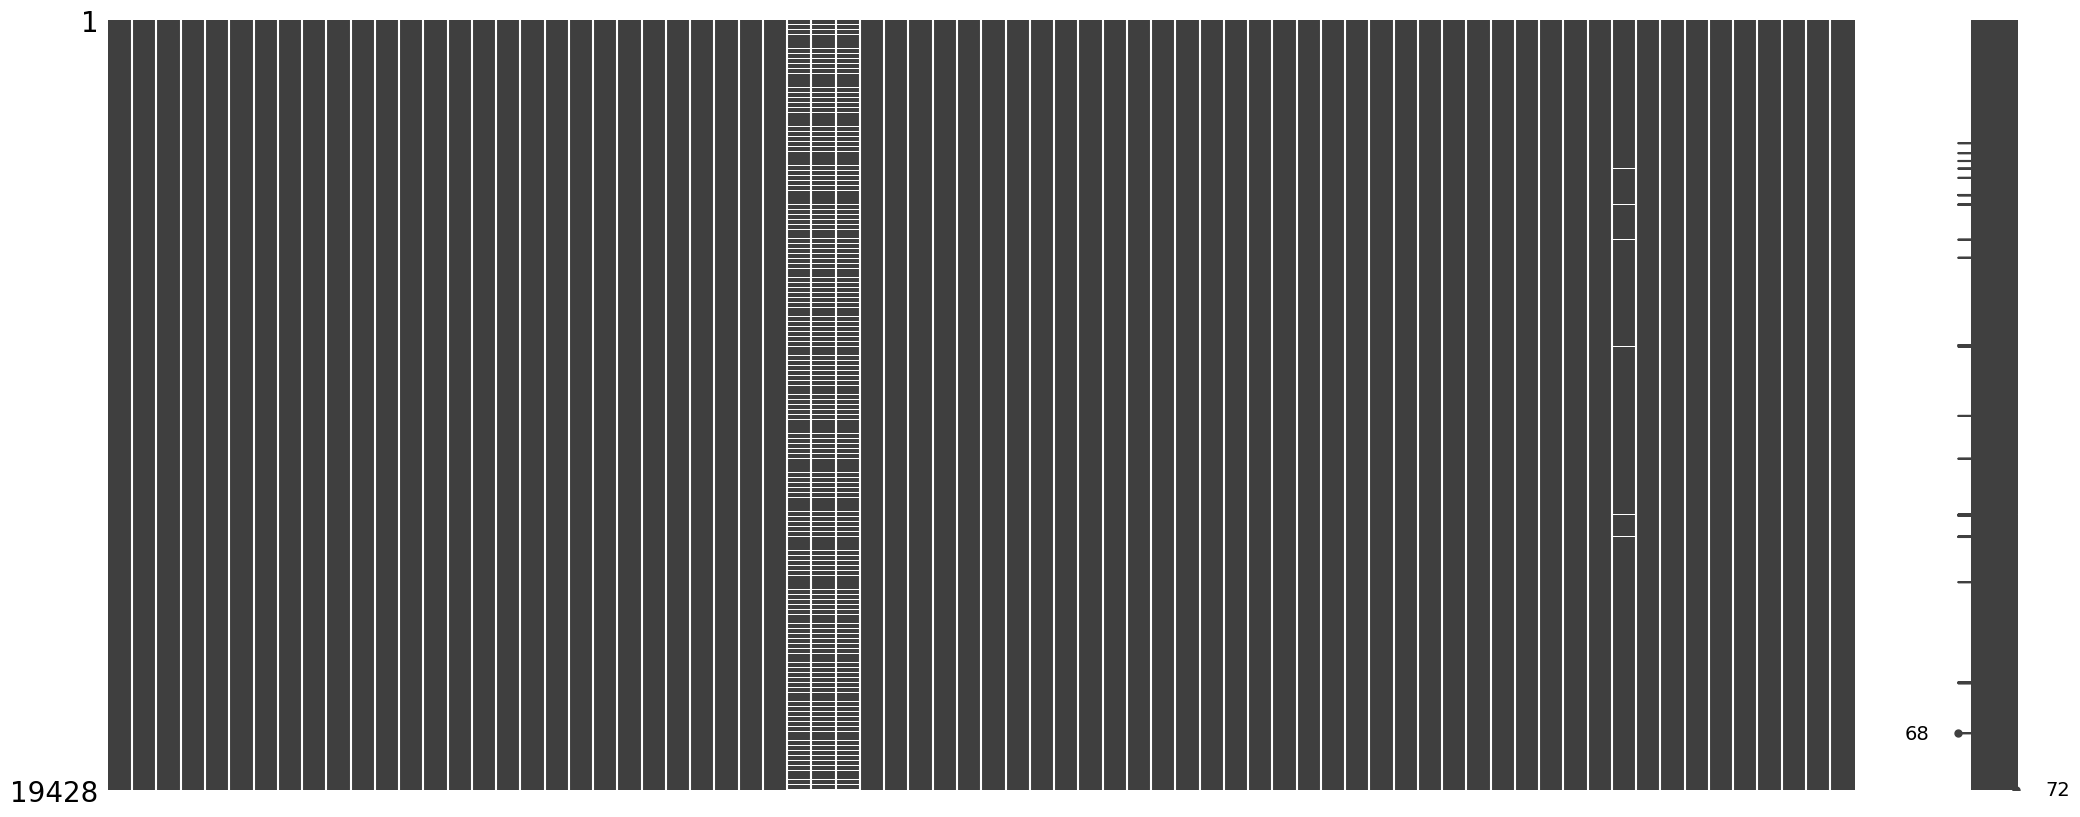

In [75]:
missingno.matrix(merged)

In [76]:
years = merged.year.unique()
years

array([2024])

In [77]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 3235, 3236, 3237], dtype=int64)

In [78]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [79]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2024,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000
1,1,2024,8.333333,17.666667,55.208333,629.814788,26.000000,-6.000000,32.000000,3.333333,13.333333,13.333333,3.333333,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000
2,2,2024,9.166667,17.333333,55.913978,547.418183,25.000000,-6.000000,31.000000,5.000000,13.333333,13.333333,5.000000,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000
3,3,2024,7.250000,18.500000,56.060606,648.652449,25.000000,-8.000000,33.000000,2.333333,12.166667,12.166667,2.333333,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000
4,4,2024,7.916667,19.166667,59.895833,564.284207,24.000000,-8.000000,32.000000,3.500000,12.333333,12.333333,3.500000,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000
5,5,2024,8.250000,21.166667,64.141414,519.374624,27.000000,-6.000000,33.000000,4.000000,12.500000,12.500000,4.000000,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000
6,6,2024,8.416667,17.833333,54.040404,668.892119,25.000000,-8.000000,33.000000,3.333333,13.500000,13.500000,3.333333,611.000000,204.000000,0.000000,68.044681,452.000000,159.000000,159.000000,452.000000
7,7,2024,9.166667,16.666667,53.763441,578.503817,24.000000,-7.000000,31.000000,4.666667,13.666667,13.666667,4.666667,611.000000,204.000000,0.000000,68.044681,452.000000,159.000000,159.000000,452.000000
8,8,2024,8.666667,15.666667,54.022989,561.842208,23.000000,-6.000000,29.000000,4.166667,13.166667,13.166667,4.166667,611.000000,204.000000,0.000000,68.044681,452.000000,159.000000,159.000000,452.000000
9,9,2024,8.166667,18.666667,58.333333,554.677083,24.000000,-8.000000,32.000000,3.666667,12.666667,12.666667,3.666667,611.000000,204.000000,0.000000,68.044681,452.000000,159.000000,159.000000,452.000000


In [80]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [81]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2024) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2024-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,1,0.371725,0.442767,-0.361823,-0.442767,0.257971,0.519864,-0.230535,-0.519864,0.137063,0.097580,0.100163,0.097580,-0.991935,-0.470645,-0.731290,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,5.160428,0.877919,33.839919,158.808756,159.973270,159.973270,-6.510000,4.110000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000
1,0,2024-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,2,0.382497,0.308098,-0.371832,-0.308098,0.316973,0.414177,-0.290961,-0.414177,0.144727,0.110431,0.107920,0.110431,-0.092759,0.509310,0.208276,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,2.444708,45.889599,45.918399,70.896519,230.869789,70.896519,-6.510000,3.470000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000
2,0,2024-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,3,0.396450,0.328166,-0.388651,-0.328166,0.360011,0.320641,-0.337045,-0.320641,0.112808,0.113910,0.076133,0.113910,4.690000,-0.168065,2.260968,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,4.030689,10.146586,21.433531,112.105071,351.790460,120.920671,-5.150000,20.790000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000
3,0,2024-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,4,0.494387,0.275380,-0.457889,-0.275380,0.469462,0.259850,-0.428911,-0.259850,0.084973,0.113481,0.051440,0.113481,21.882000,4.649200,13.265600,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,3.242630,9.256397,85.725295,94.036259,445.826719,94.036259,0.390000,26.570000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000

In [82]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [83]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [84]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [85]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [86]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

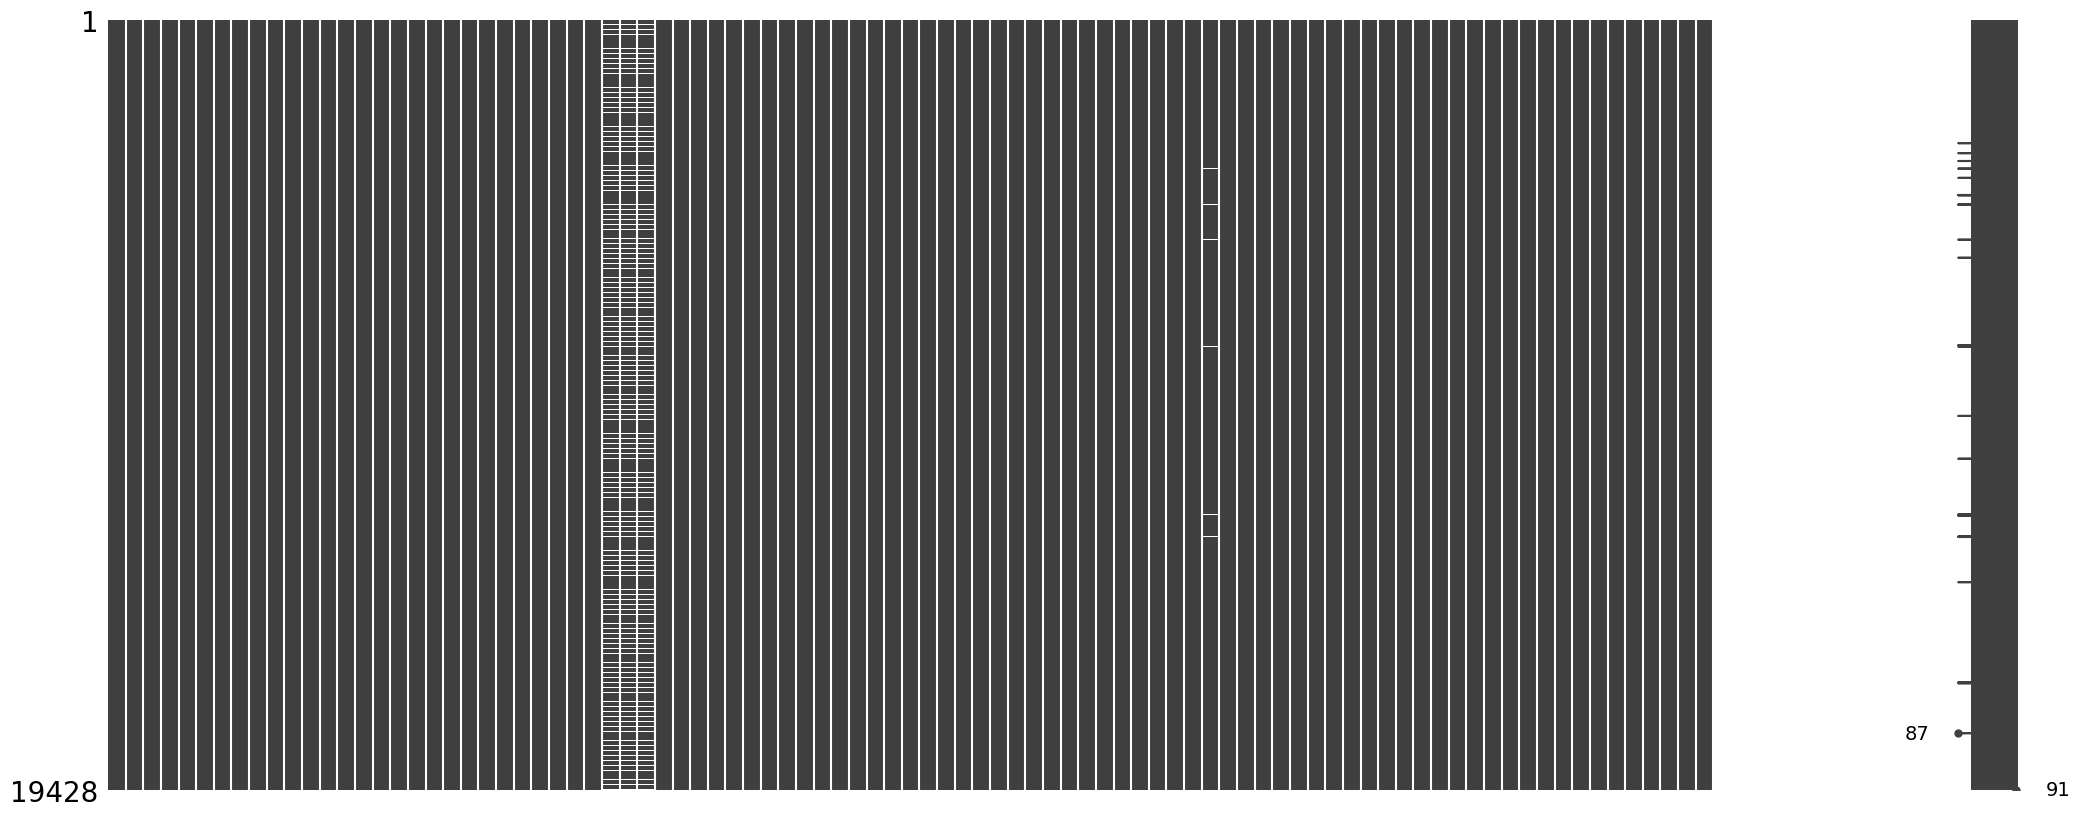

In [87]:
missingno.matrix(dataset)

In [88]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [89]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [90]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [91]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [92]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

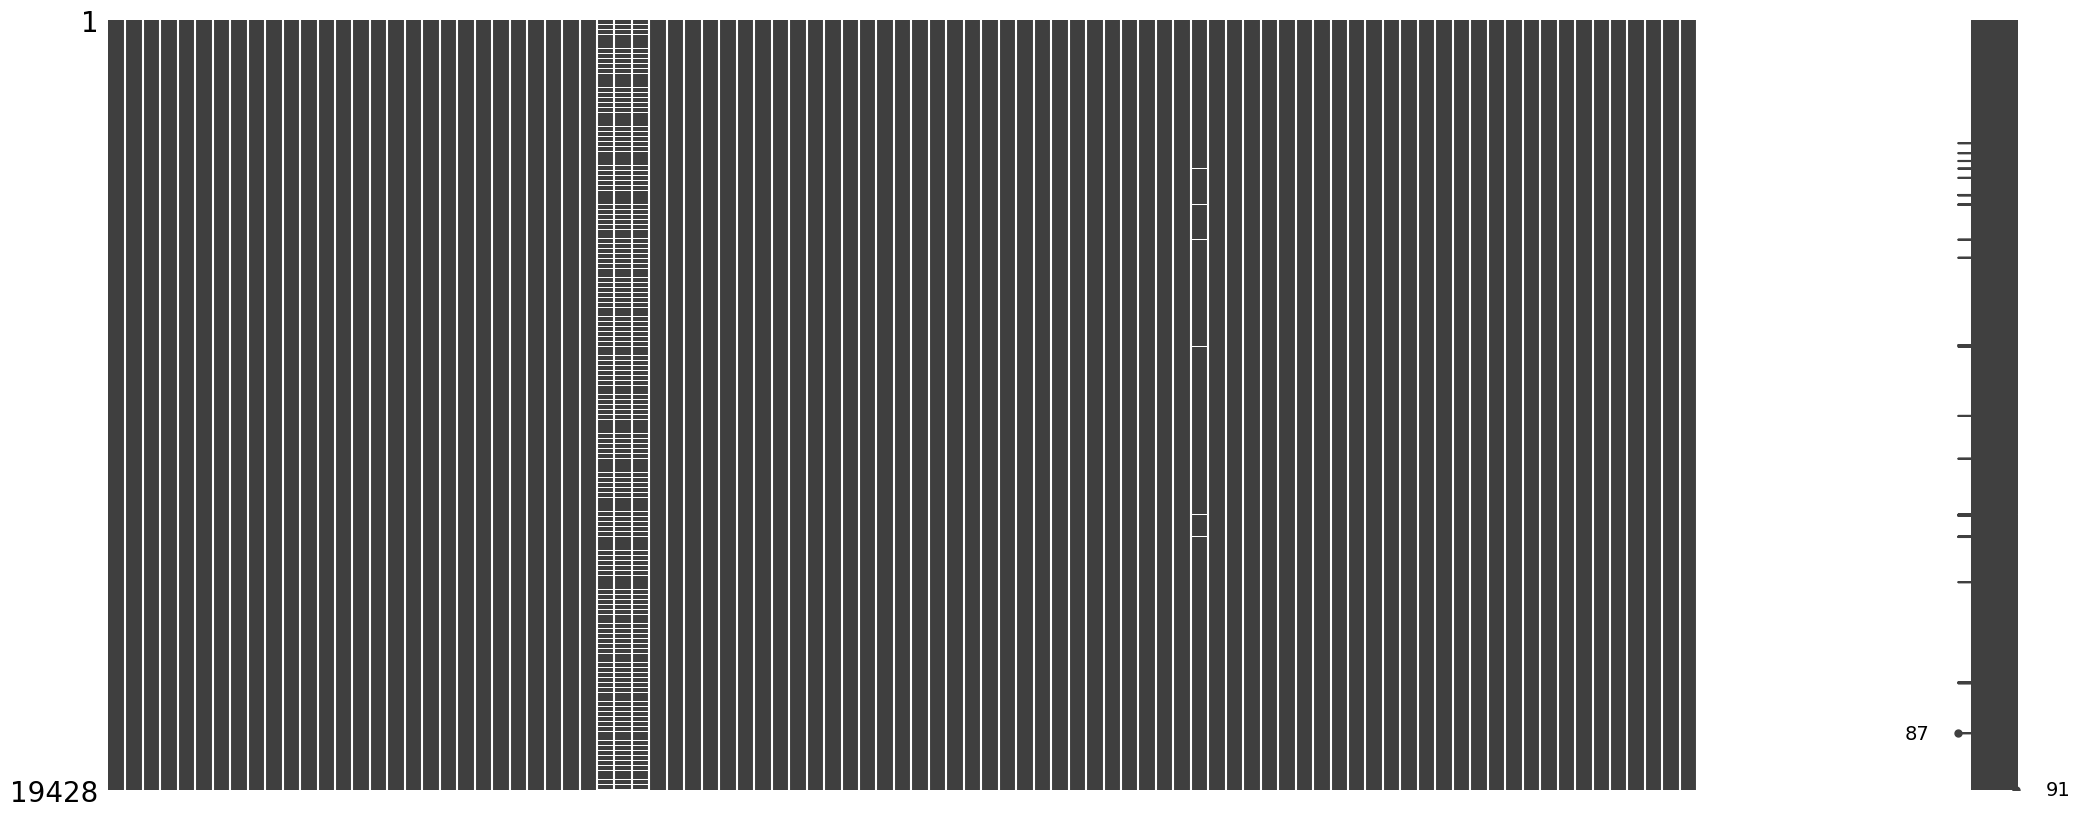

In [93]:
missingno.matrix(dataset)

In [94]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [95]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [96]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [97]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [98]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

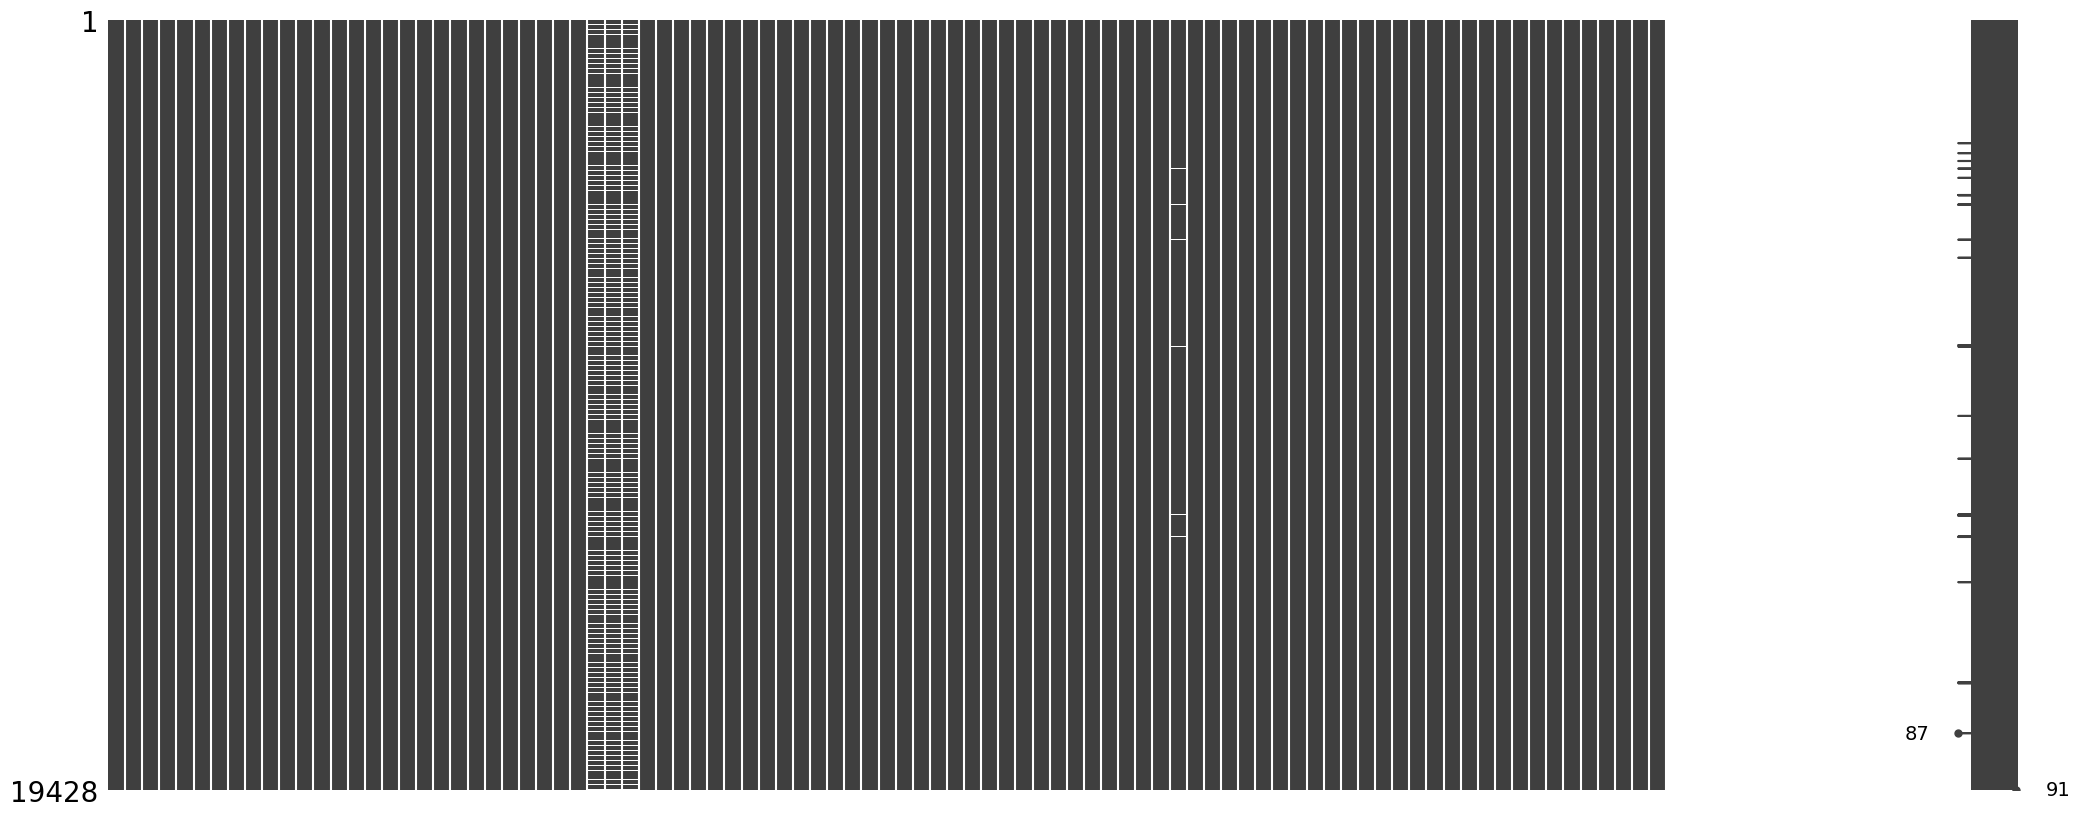

In [99]:
missingno.matrix(dataset)

In [100]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [101]:
missing

,Column,Missing
28,lst_day_mean,16.666700
29,lst_night_mean,16.666700
30,lst_mean,16.666700
62,lc_prop2_assessment,0.772100
91,M_Y_LT15,100.000000
92,M_Y15-64,100.000000
93,M_Y_GE65,100.000000
94,M_TOTAL,100.000000
95,F_Y_LT15,100.000000
96,F_Y15-64,100.000000


In [102]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2024-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,1,0.371725,0.442767,-0.361823,-0.442767,0.257971,0.519864,-0.230535,-0.519864,0.137063,0.097580,0.100163,0.097580,-0.991935,-0.470645,-0.731290,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,5.160428,0.877919,33.839919,158.808756,159.973270,159.973270,-6.510000,4.110000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2024-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,2,0.382497,0.308098,-0.371832,-0.308098,0.316973,0.414177,-0.290961,-0.414177,0.144727,0.110431,0.107920,0.110431,-0.092759,0.509310,0.208276,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,2.444708,45.889599,45.918399,70.896519,230.869789,70.896519,-6.510000,3.470000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2024-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,3,0.396450,0.328166,-0.388651,-0.328166,0.360011,0.320641,-0.337045,-0.320641,0.112808,0.113910,0.076133,0.113910,4.690000,-0.168065,2.260968,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,4.030689,10.146586,21.433531,112.105071,351.790460,120.920671,-5.150000,20.790000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2024-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,4,0.494387,0.275380,-0.457889,-0.275380,0.469462,0.259850,-0.428911,-0.259850,0.084973,0.113481,0.051440,0.113481,21.882000,4.649200,13.265600,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,3.242630,9.256397,85.725295,94.036259,445.826719,94.036259,0.390000,26.570000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0

In [103]:
dataset.reset_index(inplace=True, drop=True)

In [104]:
# dataset['cases'].value_counts()

In [105]:
# dataset['cases'].sum()

In [106]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2024-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,1,0.371725,0.442767,-0.361823,-0.442767,0.257971,0.519864,-0.230535,-0.519864,0.137063,0.097580,0.100163,0.097580,-0.991935,-0.470645,-0.731290,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,5.160428,0.877919,33.839919,158.808756,159.973270,159.973270,-6.510000,4.110000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2024-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,2,0.382497,0.308098,-0.371832,-0.308098,0.316973,0.414177,-0.290961,-0.414177,0.144727,0.110431,0.107920,0.110431,-0.092759,0.509310,0.208276,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,2.444708,45.889599,45.918399,70.896519,230.869789,70.896519,-6.510000,3.470000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2024-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,3,0.396450,0.328166,-0.388651,-0.328166,0.360011,0.320641,-0.337045,-0.320641,0.112808,0.113910,0.076133,0.113910,4.690000,-0.168065,2.260968,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,4.030689,10.146586,21.433531,112.105071,351.790460,120.920671,-5.150000,20.790000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,7.000000,19.333333,60.416667,667.083203,26.000000,-6.000000,32.000000,1.666667,12.333333,12.333333,1.666667,491.000000,159.000000,0.000000,67.304951,349.000000,142.000000,142.000000,349.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2024-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2024,4,0.494387,0.275380,-0.457889,-0.275380,0.469462,0.259850,-0.428911,-0.259850,0.084973,0.113481,0.051440,0.113481,21.882000,4.649200,13.265600,-0.991935,-0.092759,4.690000,21.882000,-0.470645,0.509310,-0.168065,4.649200,-0.731290,0.208276,2.260968,13.265600,3.242630,9.256397,85.725295,94.036259,445.826719,94.036259,0.390000,26.570000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0

In [107]:
cols = dataset.columns

In [108]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [109]:
len(cols)

102

In [110]:
years = dataset.year.unique().tolist()

In [111]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)